In [1]:
import kagglehub
path = kagglehub.dataset_download("rohitgrewal/airlines-flights-data")

100%|██████████| 2.33M/2.33M [00:00<00:00, 2.68MB/s]

Extracting files...


In [3]:
import pandas as pd

csv_file_path = os.path.join(path, file_list[0])
df = pd.read_csv(csv_file_path)

print(f"Successfully loaded {file_list[0]} into a pandas DataFrame.")
print(f"DataFrame shape: {df.shape}")
print("First 5 rows of the DataFrame:")
print(df.head())

Successfully loaded airlines_flights_data.csv into a pandas DataFrame.
DataFrame shape: (300153, 12)
First 5 rows of the DataFrame:
   index   airline   flight source_city departure_time stops   arrival_time  \
0      0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1      1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2      2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3      3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4      4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  


In [2]:
import os

# List the files in the downloaded path
file_list = os.listdir(path)
print(f"Files in the dataset directory: {file_list}")

Files in the dataset directory: ['airlines_flights_data.csv']


In [4]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB

Missing values per column:
index               0
airline             0
flight              0
source_city         0
departure_time      0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


/tmp/ipykernel_1103/3609965860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airline', y='price', data=df, palette='viridis')


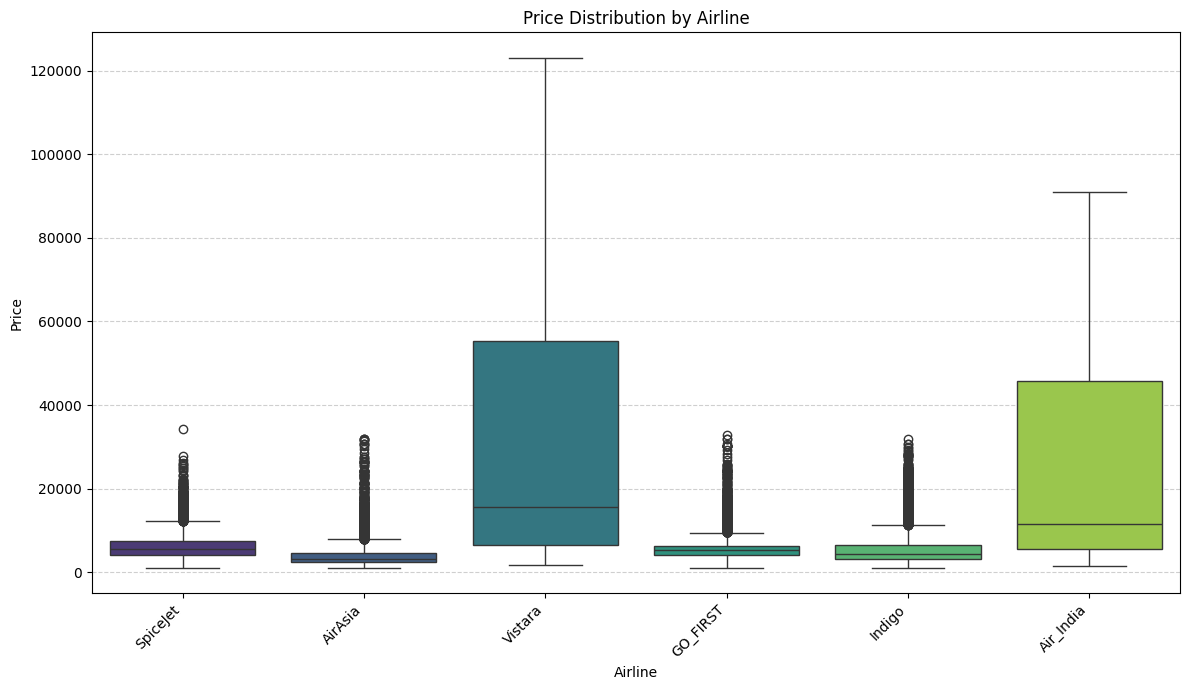

In [7]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='airline', y='price', data=df, palette='viridis')
plt.title('Price Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

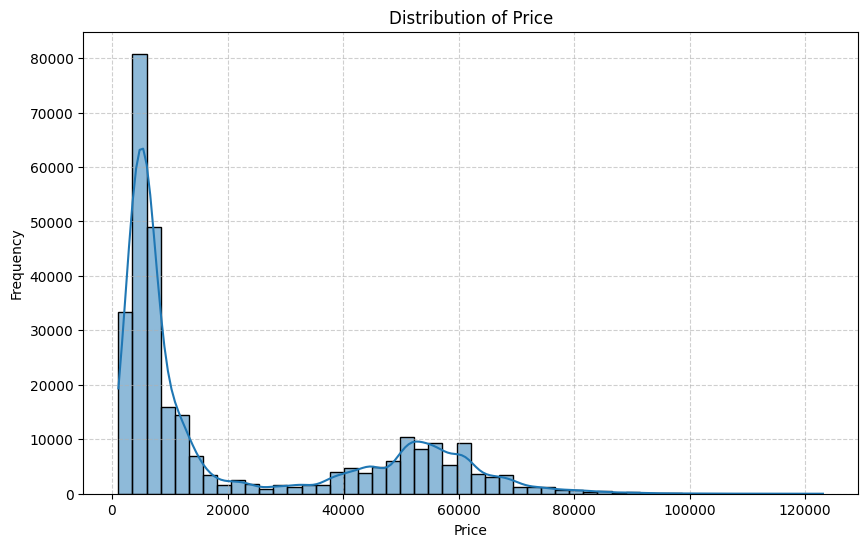

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the 'class' column
df['class_encoded'] = le.fit_transform(df['class'])

# Display the mapping of original classes to encoded values
print("Class encoding mapping:")
for i, item in enumerate(le.classes_):
    print(f"{item} : {i}")

# Display the first few rows with the new encoded column
print("\nDataFrame with encoded 'class' column:")
display(df[['class', 'class_encoded']].head())

Class encoding mapping:
Business : 0
Economy : 1

DataFrame with encoded 'class' column:


,class,class_encoded
0,Economy,1
1,Economy,1
2,Economy,1
3,Economy,1
4,Economy,1


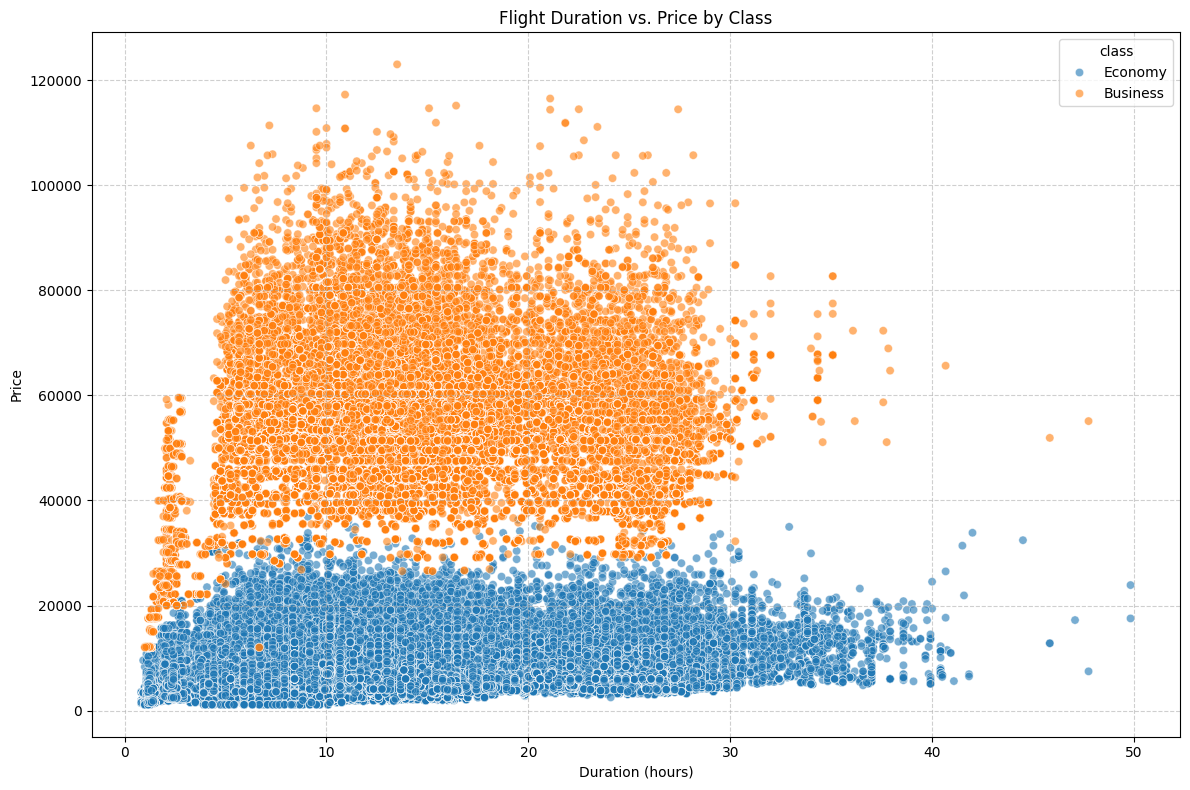

In [8]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='duration', y='price', hue='class', data=df, alpha=0.6)
plt.title('Flight Duration vs. Price by Class')
plt.xlabel('Duration (hours)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
# One-hot encode 'airline', 'source_city', and 'destination_city'
df_encoded = pd.get_dummies(df, columns=['airline', 'source_city', 'destination_city'], drop_first=True)

print("DataFrame with one-hot encoded columns (first 5 rows):")
display(df_encoded.head())
print(f"New DataFrame shape: {df_encoded.shape}")

DataFrame with one-hot encoded columns (first 5 rows):


,index,flight,departure_time,stops,arrival_time,class,duration,days_left,price,class_encoded,...,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,0,SG-8709,Evening,zero,Night,Economy,2.17,1,5953,1,...,False,True,False,False,False,False,False,False,False,True
1,1,SG-8157,Early_Morning,zero,Morning,Economy,2.33,1,5953,1,...,False,True,False,False,False,False,False,False,False,True
2,2,I5-764,Early_Morning,zero,Early_Morning,Economy,2.17,1,5956,1,...,False,True,False,False,False,False,False,False,False,True
3,3,UK-995,Morning,zero,Afternoon,Economy,2.25,1,5955,1,...,False,True,False,False,False,False,False,False,False,True
4,4,UK-963,Morning,zero,Morning,Economy,2.33,1,5955,1,...,False,True,False,False,False,False,False,False,False,True


New DataFrame shape: (300153, 25)


In [11]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder for departure_time
le_departure_time = LabelEncoder()

# Fit and transform the 'departure_time' column in the original DataFrame
df['departure_time_encoded'] = le_departure_time.fit_transform(df['departure_time'])

# Display the mapping of original departure_time categories to encoded values
print("Departure Time encoding mapping:")
for i, item in enumerate(le_departure_time.classes_):
    print(f"{item} : {i}")

# Display the first few rows with the new encoded column
print("\nDataFrame with encoded 'departure_time' column:")
display(df[['departure_time', 'departure_time_encoded']].head())

Departure Time encoding mapping:
Afternoon : 0
Early_Morning : 1
Evening : 2
Late_Night : 3
Morning : 4
Night : 5

DataFrame with encoded 'departure_time' column:


,departure_time,departure_time_encoded
0,Evening,2
1,Early_Morning,1
2,Early_Morning,1
3,Morning,4
4,Morning,4


In [13]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define target variable
y = df['price']

# Define features
numerical_features = ['duration', 'days_left']
label_encoded_features = ['class_encoded', 'departure_time_encoded']
categorical_features_for_dummies = ['airline', 'source_city', 'destination_city', 'stops', 'arrival_time']

# Combine all feature column names that will be used from the 'df' DataFrame
all_feature_cols = numerical_features + label_encoded_features + categorical_features_for_dummies

# Create the feature DataFrame X by selecting relevant columns from 'df'
X = df[all_feature_cols].copy()

# Perform one-hot encoding for the specified categorical features in X
X = pd.get_dummies(X, columns=categorical_features_for_dummies, drop_first=True)

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Shape of features (X): (300153, 26)
Shape of target (y): (300153,)

Training set size: 240122 samples
Testing set size: 60031 samples


In [14]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train RandomForestRegressor
print("\nTraining RandomForestRegressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate RandomForestRegressor
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RandomForestRegressor - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"RandomForestRegressor - R-squared (R2) Score: {r2_rf:.2f}")


Training RandomForestRegressor...
RandomForestRegressor - Mean Absolute Error (MAE): 1094.30
RandomForestRegressor - R-squared (R2) Score: 0.98


In [16]:
# Make predictions on the training set
y_pred_rf_train = rf_model.predict(X_train)

# Evaluate RandomForestRegressor on training set
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
r2_rf_train = r2_score(y_train, y_pred_rf_train)

print(f"RandomForestRegressor - Training Set MAE: {mae_rf_train:.2f}")
print(f"RandomForestRegressor - Training Set R-squared: {r2_rf_train:.2f}")

print(f"\nRandomForestRegressor - Test Set MAE: {mae_rf:.2f}")
print(f"RandomForestRegressor - Test Set R-squared: {r2_rf:.2f}")

RandomForestRegressor - Training Set MAE: 423.39
RandomForestRegressor - Training Set R-squared: 1.00

RandomForestRegressor - Test Set MAE: 1094.30
RandomForestRegressor - Test Set R-squared: 0.98


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("\nRetraining RandomForestRegressor with hyperparameter tuning...")
# Initialize and train RandomForestRegressor with new hyperparameters
rf_model_tuned = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model_tuned.fit(X_train, y_train)

# Make predictions on the training set with the tuned model
y_pred_rf_tuned_train = rf_model_tuned.predict(X_train)

# Evaluate tuned RandomForestRegressor on training set
mae_rf_tuned_train = mean_absolute_error(y_train, y_pred_rf_tuned_train)
r2_rf_tuned_train = r2_score(y_train, y_pred_rf_tuned_train)

# Make predictions on the test set with the tuned model
y_pred_rf_tuned = rf_model_tuned.predict(X_test)

# Evaluate tuned RandomForestRegressor on test set
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f"\nTuned RandomForestRegressor - Training Set MAE: {mae_rf_tuned_train:.2f}")
print(f"Tuned RandomForestRegressor - Training Set R-squared: {r2_rf_tuned_train:.2f}")
print(f"Tuned RandomForestRegressor - Test Set MAE: {mae_rf_tuned:.2f}")
print(f"Tuned RandomForestRegressor - Test Set R-squared: {r2_rf_tuned:.2f}")

print("\nOriginal RandomForestRegressor (for comparison):")
print(f"Original RandomForestRegressor - Training Set MAE: {mae_rf_train:.2f}")
print(f"Original RandomForestRegressor - Training Set R-squared: {r2_rf_train:.2f}")
print(f"Original RandomForestRegressor - Test Set MAE: {mae_rf:.2f}")
print(f"Original RandomForestRegressor - Test Set R-squared: {r2_rf:.2f}")


Retraining RandomForestRegressor with hyperparameter tuning...

Tuned RandomForestRegressor - Training Set MAE: 1697.32
Tuned RandomForestRegressor - Training Set R-squared: 0.98
Tuned RandomForestRegressor - Test Set MAE: 1813.94
Tuned RandomForestRegressor - Test Set R-squared: 0.98

Original RandomForestRegressor (for comparison):
Original RandomForestRegressor - Training Set MAE: 423.39
Original RandomForestRegressor - Training Set R-squared: 1.00
Original RandomForestRegressor - Test Set MAE: 1094.30
Original RandomForestRegressor - Test Set R-squared: 0.98


In [15]:
# Initialize and train XGBoost Regressor
print("\nTraining XGBoost Regressor...")
xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate XGBoost Regressor
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor - Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"XGBoost Regressor - R-squared (R2) Score: {r2_xgb:.2f}")


Training XGBoost Regressor...
XGBoost Regressor - Mean Absolute Error (MAE): 2023.00
XGBoost Regressor - R-squared (R2) Score: 0.98


Average Price by Airline and Class:


class,Business,Economy
airline,,
AirAsia,NaN,4091.072742
Air_India,47131.039212,7313.682169
GO_FIRST,NaN,5652.007595
Indigo,NaN,5324.216303
SpiceJet,NaN,6179.278881
Vistara,55477.027777,7806.943645


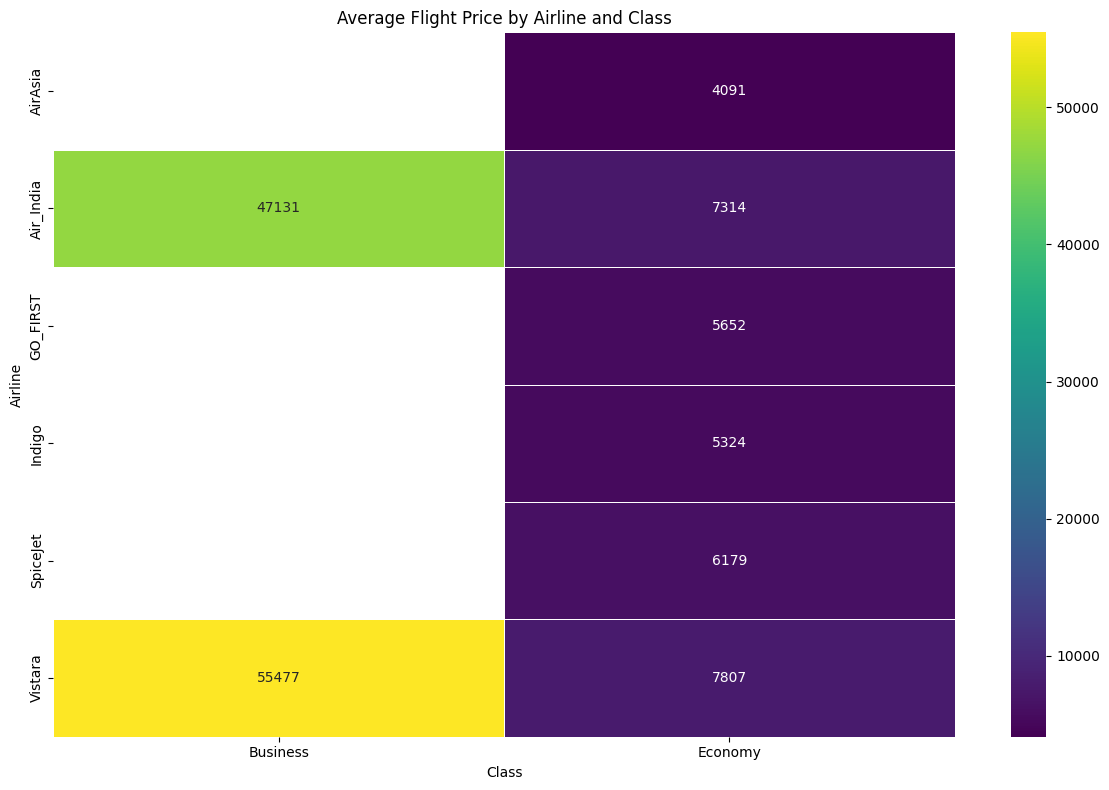


Most Expensive Business Class: Vistara with an average price of 55477
Cheapest Economy Class: AirAsia with an average price of 4091


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table for average price by airline and class
pivot_table = df.pivot_table(values='price', index='airline', columns='class', aggfunc='mean')

print("Average Price by Airline and Class:")
display(pivot_table)

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="viridis", linewidths=.5)
plt.title('Average Flight Price by Airline and Class')
plt.xlabel('Class')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

# Identify the most expensive Business class
if 'Business' in pivot_table.columns:
    most_expensive_business = pivot_table['Business'].idxmax()
    max_business_price = pivot_table['Business'].max()
    print(f"\nMost Expensive Business Class: {most_expensive_business} with an average price of {max_business_price:.0f}")

# Identify the cheapest Economy class
if 'Economy' in pivot_table.columns:
    cheapest_economy = pivot_table['Economy'].idxmin()
    min_economy_price = pivot_table['Economy'].min()
    print(f"Cheapest Economy Class: {cheapest_economy} with an average price of {min_economy_price:.0f}")

Feature Importances for Tuned RandomForestRegressor:


,feature,importance
2,class_encoded,0.900156
0,duration,0.050236
1,days_left,0.012655
4,airline_Air_India,0.005598
8,airline_Vistara,0.004938
10,source_city_Delhi,0.003728
15,destination_city_Delhi,0.003386
13,source_city_Mumbai,0.002373
3,departure_time_encoded,0.002214
18,destination_city_Mumbai,0.001951


/tmp/ipykernel_1103/1173285481.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances.head(15), palette='viridis')


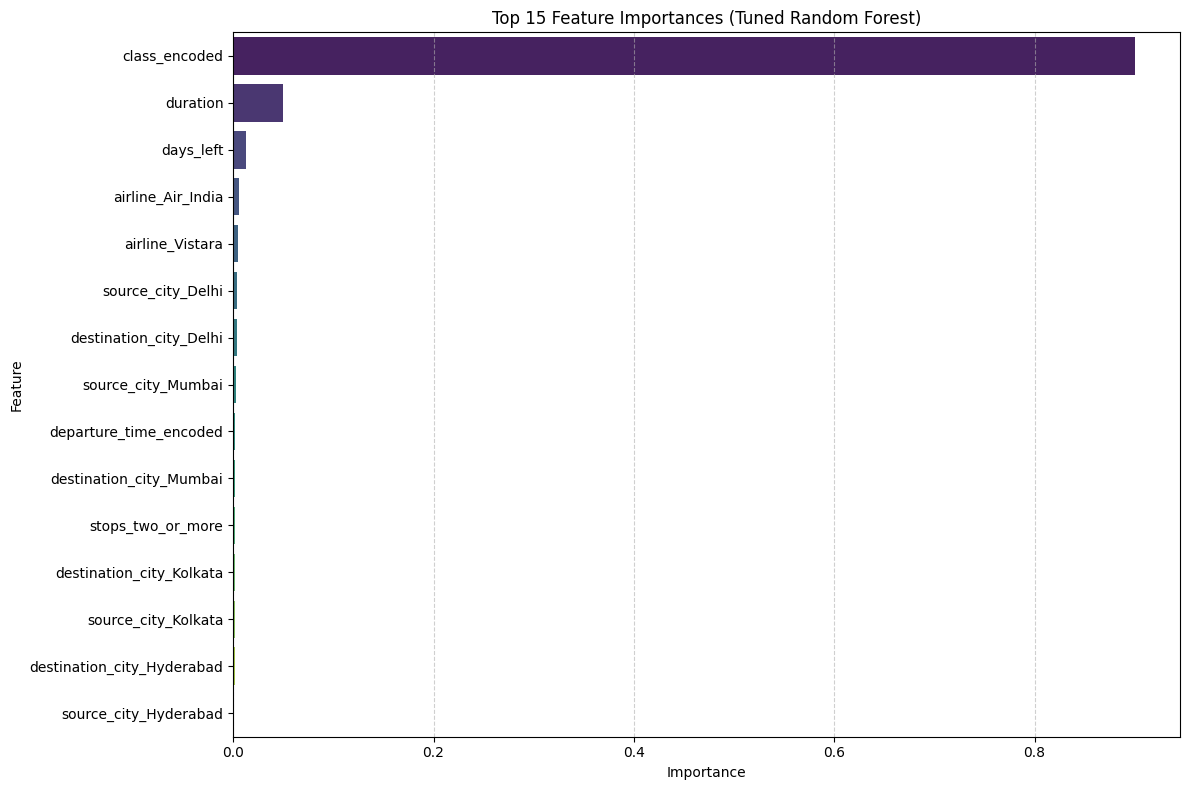

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the tuned Random Forest model
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model_tuned.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Feature Importances for Tuned RandomForestRegressor:")
display(feature_importances)

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Tuned Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred_rf_tuned
})

# Calculate the difference
comparison_df['Difference'] = comparison_df['Actual Price'] - comparison_df['Predicted Price']

print("First 10 rows of Actual vs. Predicted Prices:")
display(comparison_df.head(10))

First 10 rows of Actual vs. Predicted Prices:


,Actual Price,Predicted Price,Difference
27131,7366,6909.311818,456.688182
266857,64831,70086.393291,-5255.393291
141228,6195,6753.404720,-558.404720
288329,60160,54851.021697,5308.978303
97334,6578,6577.790835,0.209165
135931,4555,7798.599441,-3243.599441
290630,23838,23934.131818,-96.131818
141944,3860,3962.959576,-102.959576
244517,32230,46889.110087,-14659.110087
215903,76841,68302.300734,8538.699266


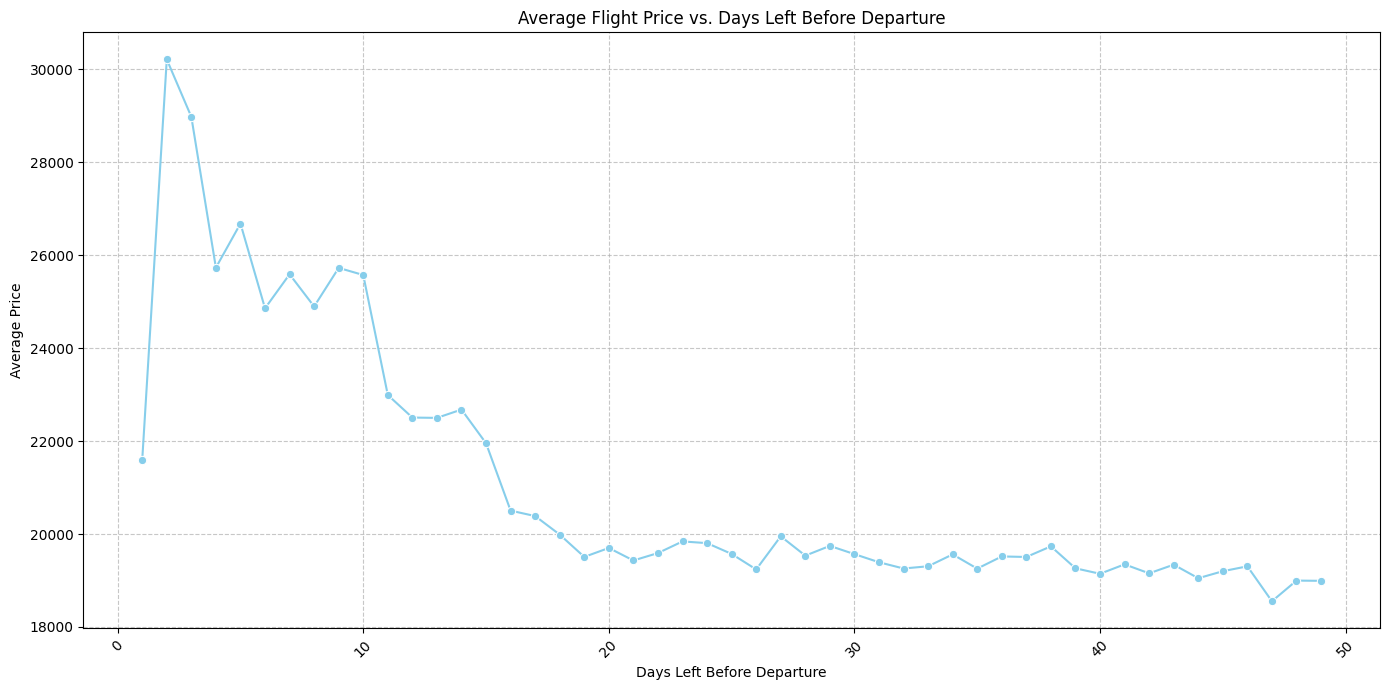

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average price for each days_left
avg_price_by_days_left = df.groupby('days_left')['price'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='days_left', y='price', data=avg_price_by_days_left, marker='o', color='skyblue')
plt.title('Average Flight Price vs. Days Left Before Departure')
plt.xlabel('Days Left Before Departure')
plt.ylabel('Average Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()